In [1]:
# Automatically reload the package if you edit the .py files
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings("ignore") # remove scanpy warnings for the tutorial.
# Import the new package name
import decipher as dc

In [2]:
dc.pl.activate_journal_quality()

# Load data

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scanpy as sc 

In [4]:
import matplotlib
print(matplotlib.__version__)
import IPython
print(IPython.__version__)

3.10.8
9.12.0


# simulated data

In [ ]:
import decipher as dc
dc.pl.activate_journal_quality()

In [9]:
delta_adata_combined = sc.read_h5ad('simulated_data/adata_june/adata_combined_delta_0.40_0.80_1.20.h5ad')
delta_adata_combined.uns["color_palette"] = None
color_palette = None

Epoch 206 (batch 20/20) | | train elbo: 137.26 (last epoch: 137.87) | val ll: 148.96:  21%|██        | 206/1000 [03:57<15:14,  1.15s/it]2026-06-05 08:10:04,275 | INFO : Early stopping has been triggered.
2026-06-05 08:10:04,329 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-06-05 08:10:04,330 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-06-05 08:10:04,338 | INFO : Saving decipher model with run_id 2026-06-05-08-10-04-bland-cerulean-cookie.


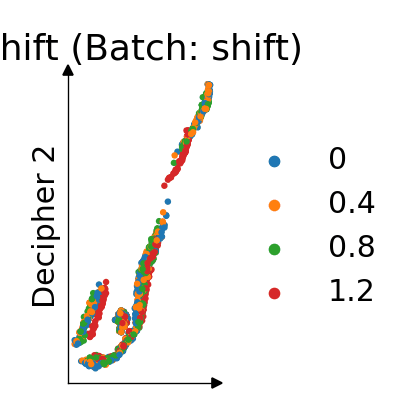

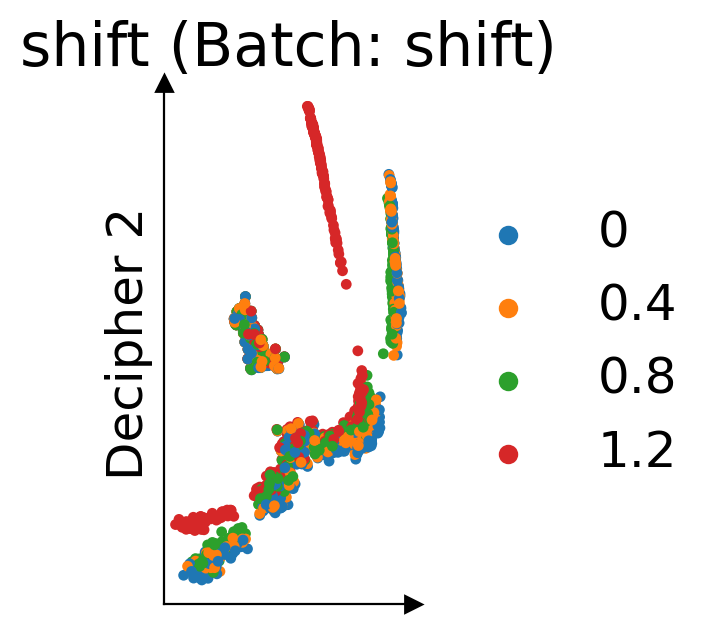

In [10]:
from decipher.tools._decipher import DecipherConfig
decipher_config = DecipherConfig(learning_rate=1e-3, seed=1)

# Train Decipher
d1, val1 = dc.tl.decipher_train(
    delta_adata_combined, decipher_config, plot_kwargs= {"color": "shift"}, 
    batch_key="shift",
    plot_every_k_epochs=5,
)

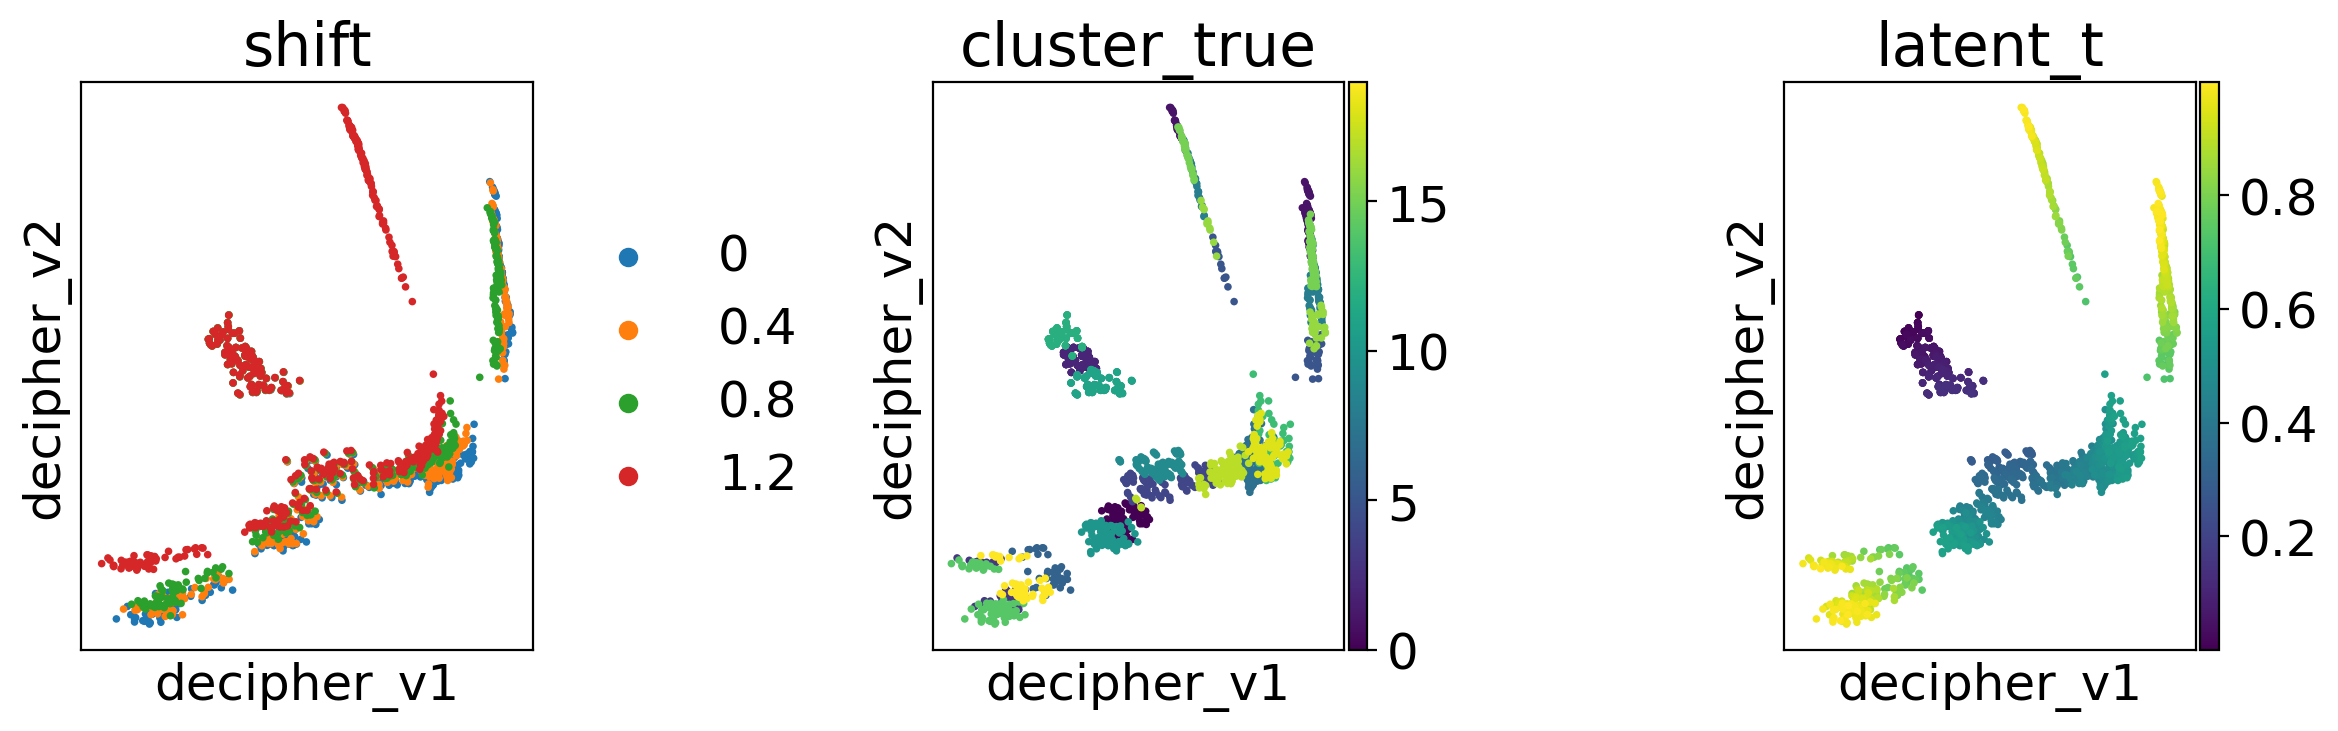

In [11]:
import logging
import pandas as pd
import scanpy as sc
import os
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns

import matplotlib as mpl

import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.metrics import silhouette_samples

decipher_z = delta_adata_combined.obsm["decipher_z"]
k_means = KMeans(20)
k_means.fit(decipher_z)
delta_adata_combined.obs["cluster_latent"] = k_means.labels_

aris = {}
for a in delta_adata_combined.obs["shift"].unique():
    mask = delta_adata_combined.obs["shift"] == a
    aris[a] = adjusted_rand_score(
        delta_adata_combined.obs["cluster_true"][mask],
        delta_adata_combined.obs["cluster_latent"][mask],
    )
#print(f"[{suffix}] aris values: {aris}")

shift_labels = delta_adata_combined.obs["shift"]
# sil_values = silhouette_samples(decipher_z, shift_labels)
# df = pd.DataFrame({"silhouette_value": sil_values, "alpha": shift_labels.values})
# print(df.groupby("alpha", observed=True)["silhouette_value"].mean())

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(4*3, 4))
# sc.pl.embedding(delta_adata_combined, basis="decipher_v", color="shift",
#                 show=False, ax=axes[0], size=30)
sc.pl.embedding(delta_adata_combined, basis="decipher_v", color="shift",
                show=False, ax=axes[0], size=30)
sc.pl.embedding(delta_adata_combined, basis="decipher_v", color="cluster_true",
                show=False, ax=axes[1], size=30)
sc.pl.embedding(delta_adata_combined, basis="decipher_v", color="latent_t",
                show=False, ax=axes[2], size=30)
plt.tight_layout()
plt.show()

In [68]:
# Before choosing what to correct for, measure which covariates actually drive
# separation in the v-space. High silhouette = strong separation = bigger effect.

from sklearn.metrics import silhouette_score

v = adata_combined.obsm['decipher_v'].copy()

# Only score covariates with at least 2 unique values and no NaNs
covariates_to_score = {
    "shift"   : adata_combined.obs["shift"].astype(str),
}

print("\n── Silhouette scores in v-space (higher = stronger separation) ──────────")
silhouette_results = {}
for name, labels in covariates_to_score.items():
    # Drop NaN rows
    mask = labels != "nan"
    if labels[mask].nunique() < 2:
        print(f"  {name:<20} skipped (< 2 unique values)")
        continue
    score = silhouette_score(v[mask], labels[mask], sample_size=5000, random_state=42)
    silhouette_results[name] = score
    print(f"  {name:<25} silhouette = {score:.4f}")  



── Silhouette scores in v-space (higher = stronger separation) ──────────
  shift                     silhouette = -0.0487
